# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Observations of Merged CRSP Data and Robintrack Data

The data sample runs from June, 1st 2018 to August, 13 2020

---

In [1]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Once the libraries are loaded, I load the data.

In [2]:
# load data
df = pd.read_csv("../../data/processed/CRSP_RH_merged.csv")

## 1. Exploratory Data Analysis

In this section, I conduct a basic EDA on this first data set.

In [3]:
# observe the missing values
df.isna().sum()

permno             0
date               0
ret                0
prc                0
vol                0
shrout             0
ticker             0
exchcd             0
users_close    41067
users_last     37037
dtype: int64

In [4]:
# length of the data frame
len(df)

1809298

In [5]:
# number of unique tickers
df["ticker"].nunique()

3797

In [6]:
df.head()

,permno,date,ret,prc,vol,shrout,ticker,exchcd,users_close,users_last
0,10026,2018-06-01,0.010097,143.05,79530.0,18702.0,JJSF,3.0,25.0,25.0
1,10026,2018-06-04,0.019504,145.84,84274.0,18702.0,JJSF,3.0,25.0,25.0
2,10026,2018-06-05,0.011040,147.45,65476.0,18702.0,JJSF,3.0,24.0,24.0
3,10026,2018-06-06,-0.008749,146.16,53421.0,18702.0,JJSF,3.0,25.0,25.0
4,10026,2018-06-07,0.000068,146.17,48654.0,18702.0,JJSF,3.0,25.0,25.0


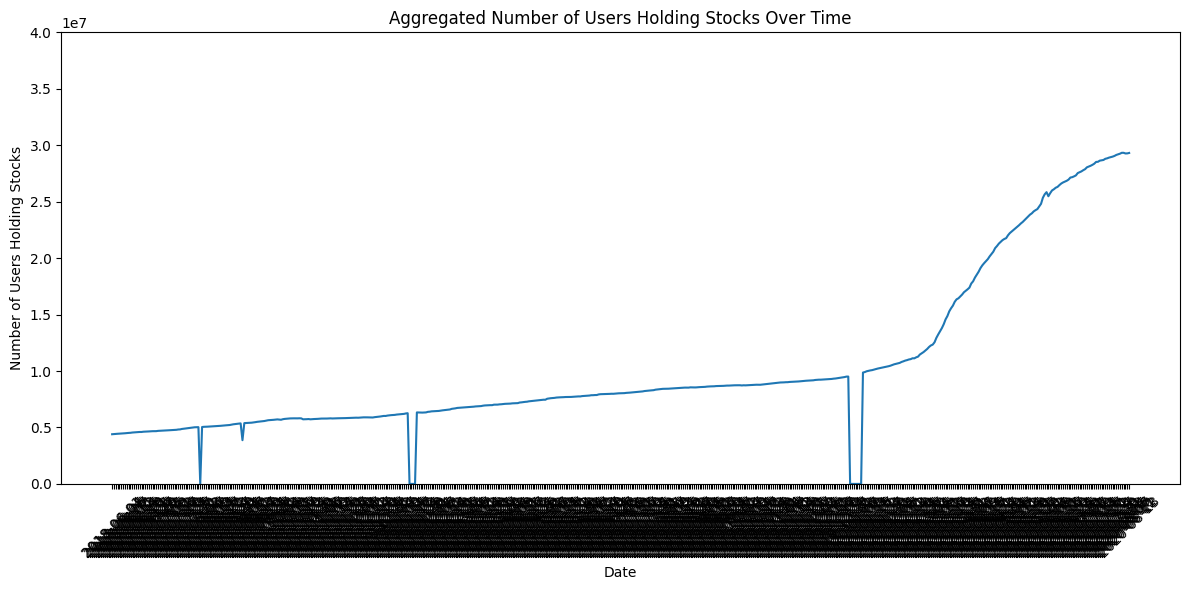

In [11]:
# for each day, compute the aggregated number of users_close
users_holding = df.groupby("date")["users_close"].sum()

# plot the aggregated number of users_close over time
plt.figure(figsize=(12, 6))
sns.lineplot(x=users_holding.index, y=users_holding.values)
plt.ylim(0, 4 * 10e6)
plt.title("Aggregated Number of Users Holding Stocks Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Users Holding Stocks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# summary statistics of users_close and users_last
df.describe().T

,count,mean,std,min,25%,50%,75%,max
permno,1809298.0,4.992022e+04,3.330619e+04,10026.000000,16063.00000,47379.00,85293.000000,9.343600e+04
ret,1809298.0,6.174628e-04,5.098231e-02,-0.916667,-0.01469,0.00,0.014141,1.025182e+01
prc,1809298.0,4.612055e+01,1.250553e+02,-753.280030,7.06000,21.01,50.120000,4.699000e+03
vol,1809298.0,1.342577e+06,5.131082e+06,0.000000,64066.00000,282883.50,972686.250000,7.062935e+08
shrout,1809298.0,1.352523e+05,4.550338e+05,9.000000,18802.00000,41619.00,97985.000000,1.013935e+07
exchcd,1809298.0,2.241979e+00,9.490392e-01,1.000000,1.00000,3.00,3.000000,3.000000e+00
users_close,1768231.0,3.202953e+03,1.997610e+04,0.000000,88.00000,305.00,1113.000000,9.439310e+05
users_last,1772261.0,3.201571e+03,1.997370e+04,0.000000,88.00000,305.00,1112.000000,9.443880e+05
